In [1]:
#pip install ordered-set

In [2]:
#pip install dill==0.3.5

In [3]:
#pip install torchviz

In [1]:
import os
os.environ["DEV"] = "1"
os.environ["NEURODIFF_API_URL"] = "http://dev.neurodiff.io"
os.environ["NEURODIFF_API_KEY"] = 'tNaaIvvvdg72-c8VcTZRgpALsl0ns77ljEvxul6tG0E'

import warnings

warnings.filterwarnings("ignore")
import dill
dill.__version__

import numpy
from NNholo_der_u_residuals import *
from tqdm.auto import tqdm



## Create directory for results

In [2]:
# Directory 
directory = "test_1"
# Parent Directory path 
parent_dir = "der_u"
# Path 
path_results = os.path.join(parent_dir, directory) 

In [3]:
os.mkdir(path_results) 
#print("Directory '% s' created" % directory) 

FileExistsError: [Errno 17] File exists: 'der_u/test_1'

File is .txt
[Parameter containing:
tensor([0.0000, 0.1333, 0.2667, 0.4000, 0.5333, 0.6667, 0.8000, 0.9333, 1.0667,
        1.2000, 1.3333, 1.4667, 1.6000, 1.7333, 1.8667, 2.0000],
       requires_grad=True), Parameter containing:
tensor([[-0.3669],
        [ 0.4178],
        [-0.1848],
        [ 0.2827],
        [-0.4514],
        [-0.8011],
        [ 0.8742],
        [-0.2694],
        [-0.8119],
        [-0.9031],
        [ 0.4841],
        [ 0.7295],
        [ 0.5897],
        [-0.1870],
        [ 0.1169],
        [-0.0683]], requires_grad=True), Parameter containing:
tensor([ 0.3720, -0.2105,  0.6665, -0.8705, -0.7698,  0.9423, -0.9815, -0.5135,
        -0.4534,  0.2839,  0.8126, -0.8122, -0.6750, -0.0586, -0.6435, -0.0681],
       requires_grad=True), Parameter containing:
tensor([[-0.0784, -0.1837, -0.0764, -0.1222,  0.2052, -0.0487,  0.0794,  0.2016,
         -0.2406,  0.1211,  0.0332,  0.1693, -0.0474,  0.0004, -0.0252,  0.0158],
        [ 0.0558,  0.1786, -0.0647, -0.1419, -0

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


S_min:  tensor(0.0002)
Length of input s(T) curve:  torch.Size([68])


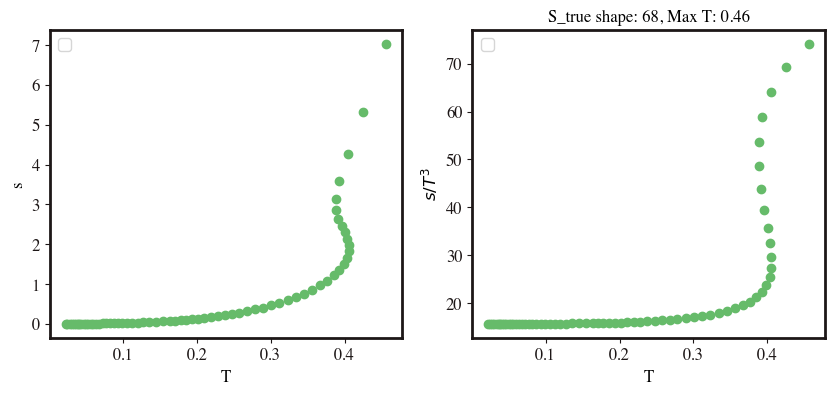

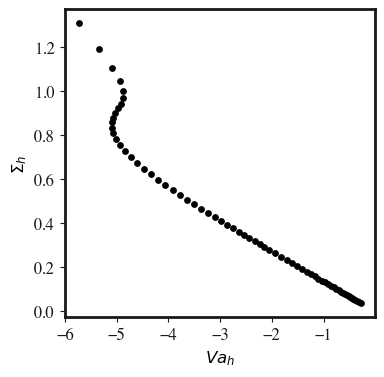

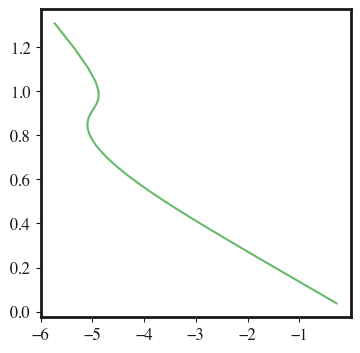

In [4]:
c = NNholo(data_path = "../Data/SofT/SofTphiM1_0.txt", \
           saving_path = path_results,n_NN_V=1)#,sampling_method='chebyshev2')
c.sofT_curve()
plt.plot(c.Va_uh_all.detach().numpy(),c.Sigma_uh_all.detach().numpy())

# BYCICLE STRUCTURE #

In [ ]:
#a = copy.deepcopy(c.nets[0].Diss_net.NN[0].weight.detach().numpy())
from neurodiffeq import diff
store_mse = Store_MSE_Loss()

scheduler = torch.optim.lr_scheduler.StepLR(c.adam, step_size=7500, gamma=0.985)
scheduler_cb = DoSchedulerStep(scheduler=scheduler)

potential_cb = BestValidationCallback()

epochs =10000
c.solver.fit(max_epochs=epochs, 
             callbacks=[potential_cb, scheduler_cb], 
             tqdm_file=tqdm(total=epochs, dynamic_ncols=True, desc='Epochs', unit='iteration', colour='#0afa9e'))

#print(a-c.nets[0].Diss_net.NN[0].weight.detach().numpy())

Epochs:   0%|                                  | 0/10000 [00:00<?, ?iteration/s]

In [ ]:
plt.plot(c.solver.metrics_history['phi_max'])
plt.show()
print(c.Va_uh_all)
plt.plot(c.pg.get_examples()[1].detach().numpy(),c.pg.get_examples()[0].detach().numpy())

In [ ]:
c.plot_loss()
#c.compare_SofT()
tf = c
c.plot_potential(phim=1.0)
phi = torch.tensor(0.0,requires_grad = True).reshape(-1,1)
print(c.V(phi))
print(diff(c.V(phi),phi))
print(diff(c.V(phi),phi,order = 2))
points = [22,48,-1]
#c.plot_residuals_in_u()
index = torch.linspace(0,tf.Va_uh_all.shape[0]-1,tf.Va_uh_all.shape[0])
u = tf.g1.get_examples()
U,IND = torch.meshgrid(u,index)
RES = []
for i in range(len(tf.Va_uh_all)):
    S = tf.Sigma_uh_all[i].detach().numpy()*np.ones_like(u.detach().numpy())
    T = tf.Va_uh_all[i].detach().numpy()*np.ones_like(u.detach().numpy())
    #print(tf.solver.get_residuals(u,S,T))
    res = tf.solver.get_residuals(u,S,T,best= False)
    RES.append(torch.stack(res).mean(dim = 0))
#print(RES)
RES = torch.log10(torch.stack(RES)**2).t()
print(RES.shape)
plt.pcolormesh(U.detach().numpy(),IND.detach().numpy(),RES.detach().numpy(),cmap='rainbow')
plt.colorbar(label = 'res$^2$')
plt.xlabel('u')
plt.ylabel('index')
plt.hlines(points[:-1],0,1,linestyle = 'dashed',color = 'black', linewidth = 3)
plt.show()
plt.plot(tf.Va_uh_all.detach().numpy(),tf.Sigma_uh_all.detach().numpy(),'.k')
for i in points:
    plt.plot(tf.Va_uh_all[i].detach().numpy(),tf.Sigma_uh_all[i].detach().numpy(),'*r')
plt.show

c.plot_colored_sofT(phiM_chosen=0.59,colormap='rainbow')

In [ ]:
x = torch.linspace(0,2,100).reshape(-1,1)
for i in range(len(c.V.VNN)):
    V1 = c.V.VNN[i](x).detach().numpy()
    plt.plot(x.detach().numpy(),V1,label= 'V ' + str(i))
plt.legend()
plt.show()
plt.plot(c.V)

In [ ]:
#c.solver_nest.get_residuals()

gen = c.solver_nest.generator['train'].get_examples()
print(gen)
print(c.solver.generator['train'].get_examples())
res = (sum(c.solver_nest.get_residuals(gen[0],gen[1],gen[2]))**2).mean()
#c.solver_nest.fit(10)
print(res)

max phi_h=  0.1551556793179684
[0.14751545 0.14749655 0.14747499 0.14745088 0.14742461 0.14739684
 0.14736862 0.14734128 0.14731632 0.14729521 0.14727899 0.14726787
 0.14726075 0.14725514 0.14724827 0.1472392  0.14723082 0.14723126
 0.14725373 0.1473141  0.14742712 0.14760266 0.14831614 0.14930188
 0.15035301 0.15131825 0.15213259 0.15278872 0.15330528 0.15370786
 0.15402067 0.15426388 0.15445343 0.15460157 0.15471769 0.15480896
 0.15488087 0.15493764 0.15498254 0.15501809 0.15504629 0.15506866
 0.15508643 0.15510056 0.15511179 0.15512073 0.15512784 0.1551335
 0.15513801 0.1551416  0.15514446 0.15514674 0.15514856 0.15515
 0.15515116 0.15515207 0.15515281 0.15515339 0.15515385 0.15515422
 0.15515452 0.15515476 0.15515494 0.15515509 0.15515521 0.15515531
 0.15515538 0.15515544 0.15515549 0.15515553 0.15515556 0.15515558
 0.1551556  0.15515562 0.15515563 0.15515564 0.15515565 0.15515565
 0.15515566 0.15515566 0.15515567 0.15515567 0.15515567 0.15515567
 0.15515567 0.15515568 0.15515568 0

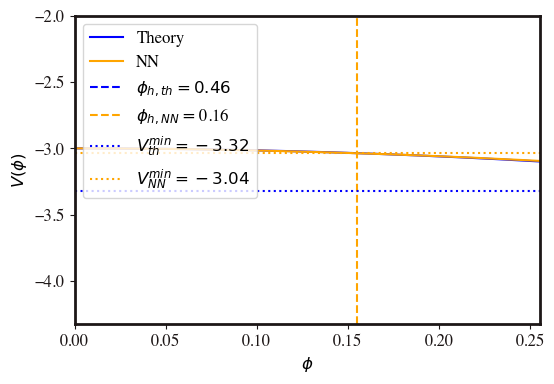

tensor([[0.]])
tensor([[-3.]], grad_fn=<AddBackward0>)
tensor([[0.]], grad_fn=<AddBackward0>)
tensor([[-3.]], grad_fn=<SubBackward0>)


In [24]:
c.plot_potential(phim=0.8,n_points=5000)
cosa=torch.reshape(torch.tensor([0.0]),[-1,1])
print(cosa)
cosa.requires_grad_(requires_grad = True)
print(diff(diff(c.V(cosa),cosa,shape_check=False),cosa,shape_check=False))
print(diff(c.V(cosa),cosa,shape_check=False))
print(c.V(cosa))

In [2]:
store_mse = Store_MSE_Loss()

scheduler = torch.optim.lr_scheduler.StepLR(c.adam, step_size=5000, gamma=0.985)
scheduler_cb = DoSchedulerStep(scheduler=scheduler)

potential_cb = BestValidationCallback()

NameError: name 'Store_MSE_Loss' is not defined

In [ ]:
#c.update_optimizer(lr = 5e-5)

In [ ]:
epochs = 1000
c.solver.fit(max_epochs=epochs, 
             callbacks=[potential_cb, scheduler_cb], 
             tqdm_file=tqdm(total=epochs, dynamic_ncols=True, desc='Epochs', unit='iteration', colour='#0afa9e'))



In [ ]:
c.plot_loss()

In [ ]:
c.plot_potential(phim=1,n_points=5000)
cosa=torch.reshape(torch.tensor([0.0]),[-1,1])
print(cosa)
cosa.requires_grad_(requires_grad = True)
print(diff(diff(c.V(cosa),cosa,shape_check=False),cosa,shape_check=False))
print(diff(c.V(cosa),cosa,shape_check=False))
print(c.V(cosa))

In [ ]:
c = NNholo(data_path = "../Data/SofT/Curve_sofT_case3of5.csv", \
    saving_path = path_results,SofT_points=int(20))#,sampling_method='chebyshev2')
c.sofT_curve()
store_mse = Store_MSE_Loss()

scheduler = torch.optim.lr_scheduler.StepLR(c.adam, step_size=5000, gamma=0.985)
scheduler_cb = DoSchedulerStep(scheduler=scheduler)

potential_cb = BestValidationCallback()
epochs = 1000000
c.solver.fit(max_epochs=epochs, 
         callbacks=[potential_cb, scheduler_cb], 
         tqdm_file=tqdm(total=epochs, dynamic_ncols=True, desc='Epochs', unit='iteration', colour='#0afa9e'))
c.plot_loss()
c.plot_potential(phim=1,n_points=5000)
cosa=torch.reshape(torch.tensor([0.0]),[-1,1])
print(cosa)
cosa.requires_grad_(requires_grad = True)
print(diff(diff(c.V(cosa),cosa,shape_check=False),cosa,shape_check=False))
print(diff(c.V(cosa),cosa,shape_check=False))
print(c.V(cosa))

In [ ]:
# DO THE LOOP TO GIVE MORE AND MORE POINTS IN THE S(T) #
number_points = np.linspace(20,30,3)
#print('Number of points: ',n)
for n in number_points:
    c = NNholo(data_path = "../Data/SofT/Curve_sofT_case3of5.csv", \
        saving_path = path_results,SofT_points=int(n))#,sampling_method='chebyshev2')
    c.sofT_curve()
    store_mse = Store_MSE_Loss()

    scheduler = torch.optim.lr_scheduler.StepLR(c.adam, step_size=5000, gamma=0.985)
    scheduler_cb = DoSchedulerStep(scheduler=scheduler)

    potential_cb = BestValidationCallback()
    epochs = 1000000
    c.solver.fit(max_epochs=epochs, 
             callbacks=[potential_cb, scheduler_cb], 
             tqdm_file=tqdm(total=epochs, dynamic_ncols=True, desc='Epochs', unit='iteration', colour='#0afa9e'))
    c.plot_loss()
    c.plot_potential(phim=1,n_points=5000)
    cosa=torch.reshape(torch.tensor([0.0]),[-1,1])
    print(cosa)
    cosa.requires_grad_(requires_grad = True)
    print(diff(diff(c.V(cosa),cosa,shape_check=False),cosa,shape_check=False))
    print(diff(c.V(cosa),cosa,shape_check=False))
    print(c.V(cosa))


In [ ]:
# SAVE #
c.save_results_new(path_results + '/NN_saved_phiM1_10_points_UV')

In [ ]:
# LOAD #
d = NNholo(data_path = "../Data/SofT/SofTphiM1_0.txt", \
           saving_path = path_results,sampling_method='chebyshev2')
d.load_results(path_results + '/NN_saved_phiM1_epochs_1000')

In [ ]:
d.solver.fit(max_epochs=50)
d.plot_loss()
d.plot_potential(phim=1.0)
#d.save_results(path_results + '/NN_new_save')

In [ ]:
# TRY TO SAVE AND LOAD THE MODEL IN A CONSISTENT WAY #
nets_state = []
for n in c.nets:
    nets_state.append(n.state_dict())
#print(nets_state)
#print(c.solver.metrics_history['r2_loss'])
#print(c.solver.global_epoch)
#print(c.adam.state_dict())
state = {'epoch': c.solver.global_epoch, 'state_dict_V': c.V.state_dict(),'state_dict_solver': nets_state,
             'optimizer': c.adam.state_dict(), 'loss': c.solver.metrics_history['r2_loss'],
        'train_loss': c.solver.metrics_history['train_loss']}
torch.save(state, path_results+'/NN_saved_'+str(c.solver.global_epoch))


In [ ]:
# TRY TO LOAD THE MODEL #

d = NNholo(data_path = "../Data/SofT/SofTphiM4_0.txt", saving_path = path_results,sampling_method="chebyshev2")

In [ ]:
#print(torch.load(path_results+'/NN_saved_1000')['state_dict_V'])
d.V.load_state_dict(torch.load(path_results+'/NN_saved_10000')['state_dict_V'])
d.solver.metrics_history['r2_loss'] = torch.load(path_results+'/NN_saved_10000')['loss']
d.solver.metrics_history['train_loss'] = torch.load(path_results+'/NN_saved_10000')['train_loss']
for i in range(len(d.nets)):
    d.nets[i].load_state_dict(torch.load(path_results+'/NN_saved_10000')['state_dict_solver'][i])
d.adam.load_state_dict(torch.load(path_results+'/NN_saved_10000')['optimizer'])
print(d.update_optimizer())

In [ ]:
d.solver.fit(max_epochs=100)
d.plot_potential(phim=4.0)
print(d.solver.global_epoch)

cosa=torch.reshape(torch.tensor([0.0]),[-1,1])
print(cosa)
cosa.requires_grad_(requires_grad = True)
print(diff(diff(f.V(cosa),cosa,shape_check=False),cosa,shape_check=False))
print(diff(f.V(cosa),cosa,shape_check=False))
print(f.V(cosa))

In [ ]:
#print(d.solver.metrics_history['r2_loss'])
plt.plot(d.solver.metrics_history['r2_loss'])
plt.yscale('log')

d.plot_loss()

In [ ]:
c.update_optimizer(5e-5)

In [ ]:
c.plot_colored_sofT(phiM_chosen = 0.58, colormap = 'jet', fontsize = 14, n_fontsize = 14, \
                          dot_size=20, thick=0.8, figsize = (8,6))

In [ ]:
c.plot_residuals_in_u()

## Saving and loading

### Save the trained model:

In [ ]:
c.save_results(f'{path_results}/trained_NN_1')

### Load the trained model: 

In [ ]:
d = NNholo(data_path = "../Data/SofT/SofTphiM3_0.txt", saving_path = path_results)#,sampling_method="chebyshev2")


In [ ]:
d.sofT_curve()

In [ ]:
d.load_results(f'{path_results}/trained_NN')

In [ ]:
store_mse = Store_MSE_Loss()

scheduler = torch.optim.lr_scheduler.StepLR(f.adam, step_size=5000, gamma=0.985)
scheduler_cb = DoSchedulerStep(scheduler=scheduler)

potential_cb = BestValidationCallback()

Add this to code of update optimizer

 if lr = False:
 
 print(lr)
 
 else:
 
 update lr

In [ ]:
d.update_optimizer(lr = 7.3e-5)

In [ ]:
d.solver.fit(max_epochs=1, callbacks=[potential_cb, scheduler_cb], \
             tqdm_file=tqdm(dynamic_ncols=True, desc='Epochs', unit='iteration', colour='#0afa9e'))



In [ ]:
d.plot_loss()

In [ ]:
d.plot_potential(phim=3.0)

In [ ]:
plt.imshow(d.V.layers[2].weight.detach().numpy())
plt.show()
plt.imshow(d.solver.nets[3].NN[2].weight.detach().numpy())
plt.show()
d.compare_to_yago()

In [ ]:
d.save_results_new(path_results + '/NN_saved_phiM3')

In [ ]:
f = NNholo(data_path = "../Data/SofT/Curve_sofT_case3of5.csv", \
           saving_path = path_results)#,sampling_method='chebyshev2')
f.load_results_new(path_results + '/NN_saved_phiM1_0_forced_epochs_2500000')

In [ ]:
epochs = 100000
f.solver.fit(max_epochs=epochs, 
             callbacks=[potential_cb, scheduler_cb], 
             tqdm_file=tqdm(total=epochs, dynamic_ncols=True, desc='Epochs', unit='iteration', colour='#0afa9e'))

In [ ]:
f.update_optimizer()
f.plot_loss()

In [ ]:
f.plot_potential(phim=1,n_points=5000)
cosa=torch.reshape(torch.tensor([0.0]),[-1,1])
print(cosa)
cosa.requires_grad_(requires_grad = True)
print(diff(diff(f.V(cosa),cosa,shape_check=False),cosa,shape_check=False))
print(diff(f.V(cosa),cosa,shape_check=False))
print(f.V(cosa))

In [ ]:
f.save_results_new(path_results + '/NN_saved_phiM1_0_forced')

In [ ]:
f.T_true

solution = f.solver.get_solution(best=True)
u = np.linspace(1, 1, 100)
sigma_UV = np.ones_like(u)*((8.939014410418975/np.pi)**(1/3))
Va_UV = np.ones_like(u)*(-0.4867126785278015*4*np.pi)


phi = solution(u,sigma_UV,Va_UV)[5]
phi_Yago = 0.6
print(phi[0]-phi_Yago)